In [38]:
import os
from typing_extensions import TypedDict
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.graph import StateGraph, add_messages
from openai import OpenAI
from rich.console import Console
from rich.panel import Panel
from rich.pretty import Pretty
from pydantic import BaseModel, Field
from langchain_tavily import TavilySearch
from rich import print
from langchain.agents import create_agent
from typing import Annotated
from rich.markdown import Markdown
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper


console = Console()

def show(response):
    console.print(
        Panel(
            Pretty(response.model_dump()),
            title="🤖 LLM Response",
            border_style="green",
            expand=False
        )
    )

def show_markdown(response):
    Console().print(Markdown(response))

load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

llm = ChatOpenAI(
    model="stepfun/step-3.5-flash:free",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)

# llm = ChatOpenAI(
#     model="deepseek/deepseek-v3.2",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="x-ai/grok-4.1-fast",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="openai/gpt-4o-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="openai/gpt-oss-120b",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="openai/gpt-5-nano",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="anthropic/claude-haiku-4.5",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="gemini-2.5-flash-lite",
#     api_key=os.getenv("GEMINI_API_KEY"),
#     base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
# )

# llm = ChatOpenAI(
#     model="gemini-2.5-flash",
#     api_key=os.getenv("GEMINI_API_KEY"),
#     base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
# )

In [28]:
class MovieModel(BaseModel):
    topic: str = Field(description="Topic for the movie")
    story: str = Field(default="", description="Story for the topic")
    analysis: str = Field(default="", description="Analysis on the scope of movie on the topic")
    report: str = Field(default="", description="Final report")


In [39]:
def storywriter(state: MovieModel) -> MovieModel:
    topic = state.topic
    tavily_tool = TavilySearch()
    api_wrapper = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=1000)
    wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper)
    agent = create_agent(
        model=llm,
        tools=[tavily_tool, wiki_tool],
        system_prompt="You are a helpful assistant. You can use tools to respond. You make a story for crating a movie based on the topic given."
    )
    response = agent.invoke({
        "messages": [{"role": "user", "content": f"Create a story on the following topic: {topic}"}]
    })
    return {'story': response['messages'][-1].content}

In [40]:
def analyzer(state: MovieModel) -> MovieModel:
    topic = state.topic
    tavily_tool = TavilySearch()
    api_wrapper = WikipediaAPIWrapper(top_k_results=3, doc_content_chars_max=1000)
    wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper)
    prompt = """
    You are a helpful assistant. You can use tools. You are given a topic on which a bollywood movie is being created.
    You have to do research and find out what budget can be expected for making this movie. Also, you have
    to estimate the earnings which can be done on this movie and weather it will be hit or flop.
    Additionally give a possible cast which will be fit for the roles in the movie.
    """
    agent = create_agent(
        model=llm,
        tools=[tavily_tool, wiki_tool],
        system_prompt=prompt
    )
    response = agent.invoke({
        "messages": [{"role": "user", "content": f"Analyze the following topic: {topic}"}]
    })
    return {'analysis': response['messages'][-1].content}

In [41]:
def director(state: MovieModel) -> MovieModel:
    story = state.story
    analysis = state.analysis
    tavily_tool = TavilySearch()
    api_wrapper = WikipediaAPIWrapper(top_k_results=3, doc_content_chars_max=1000)
    wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper)
    prompt = """
    You have been given a story and some analysis on a possible movie to be created. You have to
    create a full report from the information given. Finally respond in markdown format.
    """
    agent = create_agent(
        model=llm,
        system_prompt=prompt
    )
    response = agent.invoke({
        "messages": [{"role": "user", "content": f"Story\n: {story}\n\n\nAnalysis\n{analysis}"}]
    })
    return {'report': response['messages'][-1].content}

In [32]:
response=storywriter(MovieModel(
    topic = "Narendra Modi",
    story = "",
    analysis = "",
    report = ""
))
show(response)

╭──────────────────────────────────────────────── 🤖 LLM Response ────────────────────────────────────────────────╮
│ {                                                                                                               │
│     'topic': 'Narendra Modi',                                                                                   │
│     'story': 'In the bustling heart of Delhi, a young journalist named Anya Sharma was given the assignment of  │
│ a lifetime: to write a feature on Narendra Modi, a man who had shaped India\'s destiny for years. Anya, fresh   │
│ out of journalism school, was both thrilled and daunted. She knew the public perception was sharply divided,    │
│ and she aimed to capture a balanced, human story beyond the political rhetoric.\n\nHer journey began in the     │
│ familiar corridors of power, but she soon realized that understanding the leader required looking beyond the    │
│ headlines. She travelled to Gujarat, the state Modi had governed for over a decade. In a small village, she met │
│ an elderly woman who, with a twinkle in her eye, spoke of the improved water supply and roads that had          │
│ transformed their lives. "Before him," the woman said, "we walked for miles for a bucket of water. Now, it      │
│ comes to our homes."\n\nAnya then spent days poring over archives, speeches, and interviews. She saw the        │
│ meticulous planning behind large-scale projects, the unwavering focus on development, and the charismatic       │
│ communication style that captivated millions. Yet, she also encountered voices of dissent, concerns about       │
│ social harmony, and the immense pressure that came with such a powerful office.\n\nOne evening, while           │
│ researching in a quiet cafe, Anya overheard a conversation between two young entrepreneurs. They spoke of       │
│ "Startup India" and the renewed sense of optimism for business, attributing it to the government\'s             │
│ initiatives. "He made us believe in our own potential," one of them remarked, "that India can lead the world in │
│ innovation."\n\nAs her deadline loomed, Anya found herself wrestling with the sheer complexity of the man. He   │
│ was a figure of immense strength and resolve for some, a symbol of change and progress. For others, he          │
│ represented a shift that brought unease. She realized that Narendra Modi was not just a politician; he was a    │
│ phenomenon, a reflection of a rapidly evolving nation with diverse aspirations and challenges.\n\nHer article,  │
│ when finally published, was not a simple hagiography or a scathing critique. It was a nuanced portrait of a     │
│ leader who evoked powerful emotions, a man who had steered a nation of over a billion people through triumphs   │
│ and trials. Anya concluded her piece with a reflection: "To understand Narendra Modi is to understand the soul  │
│ of modern India – ambitious, complex, and forever in motion, striving for a future that is still being          │
│ written." Her story resonated, not because it took a side, but because it dared to explore the multifaceted     │
│ legacy of a man who continued to leave an indelible mark on the nation.',                                       │
│     'analysis': '',                                                                                             │
│     'report': ''                                                                                                │
│ }                                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [33]:
response1=analyzer(MovieModel(
    topic = "Narendra Modi",
    story = "",
    analysis = "",
    report = ""
))
show(response1)

╭──────────────────────────────────────────────── 🤖 LLM Response ────────────────────────────────────────────────╮
│ {                                                                                                               │
│     'topic': 'Narendra Modi',                                                                                   │
│     'story': '',                                                                                                │
│     'analysis': 'A Bollywood movie based on the life of Narendra Modi would be a high-profile project, likely   │
│ aiming for a grand scale, given his prominence. Here\'s an analysis:\n\n**Expected Budget:**\nBased on recent   │
│ reports of potential projects and the ambition usually associated with biopics of national leaders, the         │
│ expected budget for a new, large-scale Bollywood movie on Narendra Modi could range from **₹150 crore to ₹400+  │
│ crore**. The lower end would be for a well-produced but not overly extravagant film, while the higher end would │
│ signify a truly epic and visually rich biographical drama, utilizing extensive special effects, sets, and a     │
│ top-tier cast and crew. The previous biopic on PM Narendra Modi (released in 2019) had an estimated budget of   │
│ ₹15 crore, but a new venture would likely aim for significantly higher production values to create a more       │
│ impactful film.\n\n**Estimated Earnings and Hit/Flop Analysis:**\n\n*   **Earnings Potential:** The box office  │
│ performance would be highly dependent on the film\'s artistic merit, direction, and how it navigates the        │
│ politically charged nature of the subject.\n    *   **High End:** If the film is critically acclaimed,          │
│ resonates widely across different demographics, and leverages nationalistic sentiments effectively, it could    │
│ potentially earn **₹250 crore to ₹500 crore or more**. Films with strong nationalistic themes have historically │
│ performed well in Bollywood.\n    *   **Low End:** However, if the film is perceived as overly biased, lacks    │
│ compelling storytelling, or fails to attract a broad audience due to political polarization, earnings could be  │
│ significantly lower, potentially in the range of **₹50 crore to ₹150 crore**.\n*   **Hit or Flop:**\n    *      │
│ **Hit:** For a film with a budget of ₹150 crore, it would need to gross approximately ₹250-300 crore to be      │
│ considered a commercial hit. If the budget is at the higher end, say ₹400 crore, it would require an            │
│ exceptional box office performance of over ₹600-800 crore to be a blockbuster, which is a very challenging      │
│ target for a political biopic.\n    *   **Flop:** Given the mixed track record of Indian political biopics      │
│ (some like "Thalaivii" and "Main Atal Hoon" have had disappointing box office results despite significant       │
│ budgets), there is a considerable risk of the movie being a flop, especially if the budget is exorbitant and it │
│ struggles to achieve universal appeal. The previous Modi biopic was not a major box office success.\n*          │
│ **Overall Assessment:** It is a **high-risk, high-reward venture**. While the subject is universally            │
│ recognized, appealing to all segments of the audience can be challenging due to the contemporary political      │
│ context. It is more likely to be an **average performer to a flop** unless it delivers exceptional              │
│ storytelling, transcends political affiliations, and executes a strong marketing strategy. For it to be a true  │
│ "hit," it would require outstanding execution and widespread positive reception.\n\n**Possible                  │
│ Cast:**\n\nCasting for a biopic on Narendra Modi would require actors who can not only physically resemble the  │
│ individuals but also capture their essence and public persona.\n\n*   **For Narendra Modi:**\n    *   **Akshay  │
│ Kumar:** Known for portraying patriotic and real-life c

In [34]:
response2=director(MovieModel(
    topic = "Narendra Modi",
    story = response.story,
    analysis = response1.analysis,
    report = ""
))
show(response2)

╭──────────────────────────────────────────────── 🤖 LLM Response ────────────────────────────────────────────────╮
│ {                                                                                                               │
│     'topic': 'Narendra Modi',                                                                                   │
│     'story': 'In the bustling heart of Delhi, a young journalist named Anya Sharma was given the assignment of  │
│ a lifetime: to write a feature on Narendra Modi, a man who had shaped India\'s destiny for years. Anya, fresh   │
│ out of journalism school, was both thrilled and daunted. She knew the public perception was sharply divided,    │
│ and she aimed to capture a balanced, human story beyond the political rhetoric.\n\nHer journey began in the     │
│ familiar corridors of power, but she soon realized that understanding the leader required looking beyond the    │
│ headlines. She travelled to Gujarat, the state Modi had governed for over a decade. In a small village, she met │
│ an elderly woman who, with a twinkle in her eye, spoke of the improved water supply and roads that had          │
│ transformed their lives. "Before him," the woman said, "we walked for miles for a bucket of water. Now, it      │
│ comes to our homes."\n\nAnya then spent days poring over archives, speeches, and interviews. She saw the        │
│ meticulous planning behind large-scale projects, the unwavering focus on development, and the charismatic       │
│ communication style that captivated millions. Yet, she also encountered voices of dissent, concerns about       │
│ social harmony, and the immense pressure that came with such a powerful office.\n\nOne evening, while           │
│ researching in a quiet cafe, Anya overheard a conversation between two young entrepreneurs. They spoke of       │
│ "Startup India" and the renewed sense of optimism for business, attributing it to the government\'s             │
│ initiatives. "He made us believe in our own potential," one of them remarked, "that India can lead the world in │
│ innovation."\n\nAs her deadline loomed, Anya found herself wrestling with the sheer complexity of the man. He   │
│ was a figure of immense strength and resolve for some, a symbol of change and progress. For others, he          │
│ represented a shift that brought unease. She realized that Narendra Modi was not just a politician; he was a    │
│ phenomenon, a reflection of a rapidly evolving nation with diverse aspirations and challenges.\n\nHer article,  │
│ when finally published, was not a simple hagiography or a scathing critique. It was a nuanced portrait of a     │
│ leader who evoked powerful emotions, a man who had steered a nation of over a billion people through triumphs   │
│ and trials. Anya concluded her piece with a reflection: "To understand Narendra Modi is to understand the soul  │
│ of modern India – ambitious, complex, and forever in motion, striving for a future that is still being          │
│ written." Her story resonated, not because it took a side, but because it dared to explore the multifaceted     │
│ legacy of a man who continued to leave an indelible mark on the nation.',                                       │
│     'analysis': 'A Bollywood movie based on the life of Narendra Modi would be a high-profile project, likely   │
│ aiming for a grand scale, given his prominence. Here\'s an analysis:\n\n**Expected Budget:**\nBased on recent   │
│ reports of potential projects and the ambition usually associated with biopics of national leaders, the         │
│ expected budget for a new, large-scale Bollywood movie on Narendra Modi could range from **₹150 crore to ₹400+  │
│ crore**. The lower end would be for a well-produced but not overly extravagant film, while the higher end would │
│ signify a truly epic and visually rich biographical drama, utilizing extensive special effects, sets, and a     │
│ top-tier cast and crew. The previous biopic on PM Naren

In [35]:
show_markdown(response2.report)

Film Project Report: "Understanding Modi: A Journalist's Journey"                         

Project Overview                                                                                                   

This report presents an analysis of a potential Bollywood film project based on the provided story titled          
"Understanding Modi: A Journalist's Journey." The narrative centers on Anya Sharma, a young journalist tasked with 
creating a balanced and human portrait of Narendra Modi, India's influential leader. The film aims to explore the  
multifaceted legacy and impact of Modi through an investigative lens, rather than a straightforward chronological  
biopic.                                                                                                            

Story Synopsis: "Understanding Modi: A Journalist's Journey"                                                       

The story follows Anya Sharma, a novice journalist in Delhi, on her challenging assignment to write a feature on   
Narendra Modi. Driven by a desire to transcend political rhetoric, Anya embarks on a journey to capture a balanced 
human story. Her investigation takes her from the corridors of power to the villages of Gujarat, where she         
encounters citizens whose lives have been transformed by development initiatives like improved water supply.       

Anya delves into archives, speeches, and interviews, observing Modi's meticulous planning, focus on development,   
and charismatic communication. However, she also encounters voices of dissent and concerns about social harmony,   
highlighting the immense pressures of his office. Overhearing young entrepreneurs discuss "Startup India," Anya    
observes the renewed optimism attributed to government initiatives.                                                

As her deadline approaches, Anya grapples with the sheer complexity of Modi – a figure who evokes powerful         
emotions, representing both strength and unease. She concludes that Modi is a phenomenon, reflecting a rapidly     
evolving India with diverse aspirations. Her published article, a nuanced portrait, avoids hagiography or scathing 
critique, resonating for its exploration of a leader who left an indelible mark. Anya's concluding reflection, "To 
understand Narendra Modi is to understand the soul of modern India," encapsulates the film's potential theme.      

Movie Concept and Approach                                                                                         

The proposed film would adopt a narrative structure following Anya Sharma's journalistic investigation. This       
approach allows for a more nuanced and less direct hagiographical portrayal, exploring various perspectives on     
Modi's leadership and its impact on modern India. The film would aim to capture the ambitious, complex, and        
evolving soul of the nation through the lens of its most prominent leader.                                         

Key Themes:                                                                                                        

 • Journalistic integrity and the pursuit of truth.                                                                
 • The complexities of leadership in a diverse nation.                                                             
 • Development, economic progress, and social challenges.                                                          
 • The human impact of policy decisions.                                                                           
 • The phenomenon of a charismatic political leader.                                                               

Target Audience: The film would primarily target a broad Indian audience interested in contemporary political      
history, national development, and human-interest stories. Given Modi's widespread recognition, it would also      
attract viewers curious about the socio-political landscape of modern 

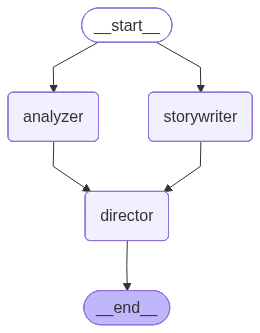

In [42]:
graph = StateGraph(MovieModel)

graph.add_node("storywriter", storywriter)
graph.add_node("analyzer", analyzer)
graph.add_node("director", director)

graph.add_edge(START, "storywriter")
graph.add_edge(START, "analyzer")
graph.add_edge("storywriter", "director")
graph.add_edge("analyzer", "director")
graph.add_edge("director", END)

movie_graph = graph.compile()

from IPython.display import Image, display
Image(movie_graph.get_graph().draw_mermaid_png())

In [ ]:
response=movie_graph.invoke(MovieModel(
    topic = "Narendra Modi",
    story = "",
    analysis = "",
    report = ""
))

AttributeError: 'dict' object has no attribute 'report'

In [46]:
show_markdown(response['report'])

Film Development Report: "The Tea Seller's Dream"                                 

Executive Summary                                                                                                  

This report analyzes the proposed Bollywood film "The Tea Seller's Dream," a fictionalized inspirational biopic    
inspired by the life journey of Narendra Modi. The narrative follows "Naren," a tea seller at Vadodara Junction who
rises to become a visionary Prime Minister through grassroots service, education, and developmental leadership.    
Based on a comprehensive assessment of the provided story and market analysis, the film presents a high-risk,      
high-concept project with significant cultural resonance but substantial commercial and political challenges. Its  
success hinges on nuanced storytelling, strategic casting, and meticulous release planning.                        

-------------------------------------------------------------------------------------------------------------------

1. Story & Narrative Analysis                                                                                      

Core Themes                                                                                                        

 • Service as Justice: Positions public service not as charity but as a fundamental right and duty.                
 • Grassroots to Governance: The classic "from the people, by the people" arc, emphasizing listening and bottom-up 
   problem-solving.                                                                                                
 • Developmental Vision: Focuses on tangible infrastructure (roads, schools, toilets, digital connectivity) as     
   pillars of dignity and progress.                                                                                
 • Quiet Leadership: Contrasts loud politics with patient, on-ground action and consensus-building.                
 • Symbolism of Tea: The tea stall serves as a recurring motif for connection, observation, and rootedness.        

Narrative Strengths                                                                                                

 • Universal Appeal: The "underdog to leader" story transcends specific political affiliation for many viewers.    
 • Emotional Anchors: Key moments (free chai to the old man, gift of the Constitution, cyclone rescue) are         
   powerfully human and relatable.                                                                                 
 • Clear Act Structure: Easy to adapt into a three-act film (The Stall, The Organizer, The Leader).                
 • Inspirational Tone: Aligns with successful Bollywood motivational biopics (e.g., Dangal, MS Dhoni).             

Narrative Risks & Sensitivities                                                                                    

 • OvertPolitical Parallel: While fictionalized, the parallels to Narendra Modi are unmistakable. This immediately 
   polarizes the audience.                                                                                         
 • Hagiographic Tone: The story presents an almost unblemished heroic journey. To avoid criticism, the script must 
   introduce meaningful internal or external conflicts, failures, or ethical dilemmas (e.g., the saboteurs of the  
   bridge project are a start) to add dramatic depth and realism.                                                  
 • Simplification of Complex Politics: The resolution of major issues (land disputes, cyclone coordination) is     
   portrayed as a result of personal will. A more nuanced approach would acknowledge systemic and bureaucratic     
   hurdles beyond one person's control.                                                                            

-------------------------------------------------------------------------------------------------------------------

2. Production & Commercial Analysis                                          

### Summary of the Flow

Input: You can pass either a dict or a MovieModel object to invoke().
Processing: Inside the nodes, LangGraph treats the state as a MovieModel object (allowing you to use state.topic).
Output: invoke() returns a dictionary representing the final snapshot of the state.

If you want the Pydantic object back
If your downstream code requires a Pydantic instance (e.g., for further validation or to use Pydantic methods), you can easily convert the dictionary back into your model:
python

#### Convert the dictionary output back to your Pydantic class
final_object = MovieModel(**final_state)

print(type(final_object)) # <class 'MovieModel'>
print(final_object.report) # Now you can use dot notation again